
import lib  
dataset (student hour/employee)  
declare the independent and dependent variable  
split the data  
call the linear regression model  
training  
calculate evaluation metrices(mse, rmse, r^2)  
evaulate the regression line  


In [1]:
# Imports

import kagglehub
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from kagglehub import KaggleDatasetAdapter

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

In [2]:
# Load dataset
file_path = "placement.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "tann22u/placement-dataset",
    file_path
)

df.head()

100%|██████████| 2.13k/2.13k [00:00<00:00, 3.82MB/s]


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [3]:
# Identify the dependent and independent variable
X = df[['cgpa']]
y = df['package']
display(X.head())
display(y.head())

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94


,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57


In [6]:
display(df.info())
display(df.head())
display(df.describe())
display(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


None

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


Index(['cgpa', 'package'], dtype='object')

In [7]:
# Training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Call the linear regression model
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [9]:
print("Actual:")
print(y_test.values)

print("Predicted:")
print(y_pred)

Actual:
[2.79 3.23 3.26 3.04 3.34 4.21 2.94 2.87 2.99 3.58 1.63 2.08 4.08 2.21
 3.47 3.64 2.74 3.08 2.17 2.99 2.31 2.35 3.4  3.08 3.81 2.19 1.53 2.89
 3.16 2.48 3.51 2.98 3.39 3.28 2.73 3.74 2.6  3.13 3.82 3.15]
Predicted:
[2.78031348 3.13635249 3.1995207  2.38981908 3.52684689 3.76803461
 3.16506531 2.54486832 3.17655044 3.4923915  1.90744364 2.34962112
 3.6876387  2.75734322 3.47516381 3.04447145 2.32665086 3.20526327
 2.17734418 3.314372   2.45298729 2.90090734 3.32011456 2.87219451
 3.33734226 2.19457187 1.41932564 2.7114027  3.18229301 2.32665086
 3.74506435 2.95833298 3.68189614 2.97556068 2.59080884 3.34882738
 2.47595755 3.07318428 4.17575671 2.95833298]


In [10]:
# Calculate the evaluation metrices
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MEAN SQUARE ERROR     : ", mse)
print("ROOT MEAN SQUARE ERROR: ", rmse)
print("R^2 score             : ", r2)

MEAN SQUARE ERROR     :  0.08417638361329656
ROOT MEAN SQUARE ERROR:  0.2901316659954521
R^2 score             :  0.7730984312051673


In [11]:
# Regression equation
print("INTERCEPT  : ", model.intercept_)
print("COEFFICIENT: ", model.coef_)

print(f"REGRESSION EQUATION:\nPACKAGE = {model.intercept_:.4f} + {model.coef_[0]:.4f} * CGPA")

INTERCEPT  :  -1.0270069374542108
COEFFICIENT:  [0.57425647]
REGRESSION EQUATION:
PACKAGE = -1.0270 + 0.5743 * CGPA


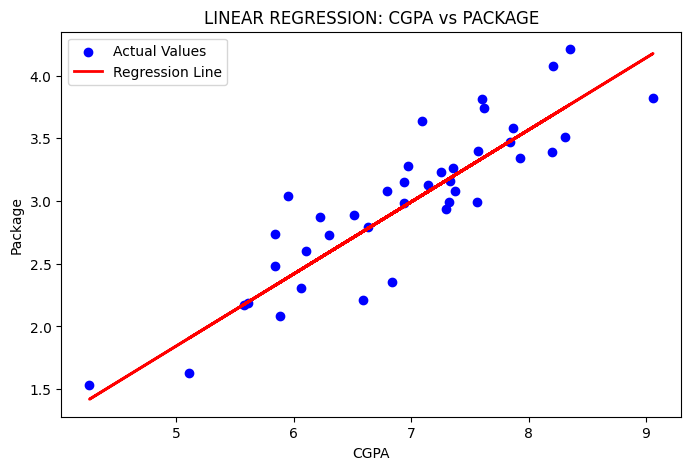

In [12]:
# Evaluate the regression line
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test,
    y_test,
    color="blue",
    label="Actual Values"
)

plt.plot(
    X_test,
    y_pred,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("LINEAR REGRESSION: CGPA vs PACKAGE")
plt.legend()
plt.show()

In [13]:
new_cgpa = [[9.67]]

prediction = model.predict(new_cgpa)

print("Predicted package: ", prediction[0])

Predicted package:  4.526053153573352


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
